# Convex-Cost Swing Option: RL vs LSM

> Comparative diagnostics for the convex frictions experiment (`c_cost=0.04`, `gamma_cost=2.0`) using the evaluation logs at `logs/SwingOption_20_c0.04_gamma2_13`. The focus is on pricing accuracy, allocation behaviour, and how convex exercise frictions propagate through both the Longstaff–Schwartz benchmark and the reinforcement learning policy.

## Research framing
- Monthly HHK swing contract: 22 exercise rights, $Q_{\max}=20$, strike $K=1.0$, refraction disabled.
- Experiment introduces convex execution frictions governed by $c_{\text{cost}}=0.04$ and $\gamma_{\text{cost}}=2.0$.
- Goal: quantify how RL and LSM differ in **pricing**, **exercise timing**, **quantity allocation**, and **cost efficiency** under convex frictions.
- Approach: load evaluation CSVs, engineer discounted payoffs and cost decompositions, and contrast distributions/behaviours with statistical tests plus visual diagnostics.

In [1]:
# Core analysis stack (Matplotlib + SciencePlots)
import warnings
from pathlib import Path
from typing import Dict, Tuple
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

try:
    import scienceplots  # noqa: F401
    plt.style.use(['science', 'no-latex'])
except Exception:
    # scienceplots optional; fall back to a clean built-in style
    plt.style.use('seaborn-v0_8-whitegrid')
pd.options.mode.chained_assignment = None
sns.set_context("paper")

In [2]:
# File locations and contract parameters (v65 C++ focal g2 agent)
REPO_ROOT = Path("/Users/alexanderithakis/Documents/GitHub/DRL-Swing-Options")
DATA_ROOT = REPO_ROOT / "logs" / "SwingOption_20_c0.04_gamma2_v65_13" / "evaluations"
RL_PATH = DATA_ROOT / "rl_episode_4096.parquet"
LSM_PATH = REPO_ROOT / "logs" / "lsm_full_state" / "SwingOption_20_c0.04_gamma2_v65_lsm.parquet"
assert LSM_PATH.exists() and RL_PATH.exists(), "Evaluation parquets missing - run tools/gen_nb6_v65.py"
K = 1.0
R = 0.05
MATURITY = 0.0833  # ~1 month
N_RIGHTS = 22
DT = MATURITY / N_RIGHTS
Q_MAX = 20.0
C_COST = 0.04
GAMMA_COST = 2.0
DISCOUNT = np.exp(-R * DT * (np.arange(N_RIGHTS) + 1))
print(f"Δt = {DT:.5f}, discount[0] = {DISCOUNT[0]:.6f}")

Δt = 0.00379, discount[0] = 0.999811


In [3]:
def _parquet_available_columns(path: Path) -> set[str]:
    """Return available parquet columns (best-effort)."""
    try:
        import pyarrow.parquet as pq
    except Exception:
        return set()
    try:
        return set(pq.ParquetFile(path).schema.names)
    except Exception:
        return set()


def read_parquet_select(path: Path, columns: list[str] | None = None) -> pd.DataFrame:
    """Read parquet selecting only columns that exist (reduces RAM)."""
    if columns is None:
        return pd.read_parquet(path)
    available = _parquet_available_columns(path)
    if not available:
        # Fallback if schema introspection isn't available.
        return pd.read_parquet(path)
    cols = [c for c in columns if c in available]
    return pd.read_parquet(path, columns=cols)


def downcast_df(df: pd.DataFrame) -> pd.DataFrame:
    """Downcast numeric dtypes to reduce memory footprint."""
    df = df.copy()
    for col in df.columns:
        if pd.api.types.is_float_dtype(df[col]):
            df[col] = pd.to_numeric(df[col], downcast='float')
        elif pd.api.types.is_integer_dtype(df[col]):
            df[col] = pd.to_numeric(df[col], downcast='integer')
    return df


def clean_columns(df: pd.DataFrame) -> pd.DataFrame:
    df.columns = [c.strip().lower() for c in df.columns]
    return df


def add_discounting(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df['time_step'] = pd.to_numeric(df['time_step'], downcast='integer').astype(int)
    df['discount'] = np.exp(-R * DT * (df['time_step'] + 1)).astype(np.float32)
    return df


def prepare_lsm(path: Path) -> pd.DataFrame:
    # Load only what we use downstream.
    cols = ['path', 'time_step', 'spot', 'q_t', 'payoff', 'payoff_gross', 'exercise_cost']
    df = clean_columns(read_parquet_select(path, cols))
    df = add_discounting(df)
    df['pv_net'] = (df['payoff'] * df['discount']).astype(np.float32)
    df['pv_gross'] = (df['payoff_gross'] * df['discount']).astype(np.float32)
    df['pv_cost'] = (df['exercise_cost'] * df['discount']).astype(np.float32)
    df['costs'] = df['exercise_cost']
    df['costs_discounted'] = df['pv_cost']
    df['method'] = 'LSM'
    df = downcast_df(df)
    df['method'] = df['method'].astype('category')
    return df


def prepare_rl(path: Path) -> pd.DataFrame:
    # Load only what we use downstream (extras included if present).
    cols = [
        'path', 'time_step', 'spot', 'q_t', 'reward', 'payoff',
        'spot_minus_strike', 'q_exercised_norm', 'q_remaining_norm'
    ]
    df = clean_columns(read_parquet_select(path, cols))
    df = add_discounting(df)
    intrinsic = df['spot_minus_strike'] if 'spot_minus_strike' in df.columns else (df['spot'] - K)
    df['gross_payoff'] = (np.maximum(intrinsic, 0.0) * df['q_t']).astype(np.float32)
    df['exercise_cost_model'] = (C_COST * np.power(np.clip(df['q_t'], 0.0, None), GAMMA_COST)).astype(np.float32)
    df['pv_gross'] = (df['gross_payoff'] * df['discount']).astype(np.float32)
    df['pv_cost'] = (df['exercise_cost_model'] * df['discount']).astype(np.float32)
    df['net_payoff'] = df['reward'] if 'reward' in df.columns else df['payoff']
    # RL reward is already a discounted increment in this project; don't re-discount.
    df['pv_net'] = df['net_payoff'] if 'reward' in df.columns else (df['net_payoff'] * df['discount'])
    df['reward_raw'] = df['reward'] if 'reward' in df.columns else np.nan
    df['costs'] = np.maximum(df['gross_payoff'] - df['net_payoff'], 0.0).astype(np.float32)
    df['costs_discounted'] = (df['costs'] * df['discount']).astype(np.float32)
    if 'q_exercised_norm' in df.columns:
        df['q_exercised'] = (df['q_exercised_norm'] * Q_MAX).astype(np.float32)
    if 'q_remaining_norm' in df.columns:
        df['q_remaining'] = (df['q_remaining_norm'] * Q_MAX).astype(np.float32)
    df['method'] = 'RL'
    df = downcast_df(df)
    df['method'] = df['method'].astype('category')
    return df


def per_path_metrics(df: pd.DataFrame) -> pd.DataFrame:
    g = df.groupby(['method', 'path'], as_index=False, observed=False)
    agg = g.agg(
        PV_net=('pv_net', 'sum'),
        PV_gross=('pv_gross', 'sum'),
        PV_cost=('pv_cost', 'sum'),
        Q_total=('q_t', 'sum'),
        Costs_total=('costs', 'sum'),
        Costs_discounted_total=('costs_discounted', 'sum')
    )
    first_ex = (
        df.loc[df['q_t'] > 1e-8, ['method', 'path', 'time_step']]
        .groupby(['method', 'path'],observed=False)['time_step']
        .min()
        .rename('first_ex')
        .reset_index()
    )
    agg = agg.merge(first_ex, on=['method', 'path'], how='left')
    agg['PV_margin_pct'] = np.where(agg['PV_gross'] > 0, 1 - agg['PV_net'] / agg['PV_gross'], np.nan)
    return agg

In [4]:
lsm_df = prepare_lsm(LSM_PATH)
rl_df = prepare_rl(RL_PATH)

print(f"LSM rows: {len(lsm_df):,} | RL rows: {len(rl_df):,}")
all_cols = sorted(set(lsm_df.columns).union(set(rl_df.columns)))
print(f"Columns: {all_cols[:10]} ...")
if 'reward_raw' in rl_df.columns and 'pv_net' in rl_df.columns:
    rl_diff = (rl_df['pv_net'] - rl_df['reward_raw']).abs().max()
    print(f"Max abs difference between pv_net and raw reward: {rl_diff:.3e}")

LSM rows: 360,448 | RL rows: 360,448
Columns: ['costs', 'costs_discounted', 'discount', 'exercise_cost', 'exercise_cost_model', 'gross_payoff', 'method', 'net_payoff', 'path', 'payoff'] ...
Max abs difference between pv_net and raw reward: 0.000e+00


In [5]:
path_stats = pd.concat([per_path_metrics(lsm_df), per_path_metrics(rl_df)], ignore_index=True)
path_stats.head()

,method,path,PV_net,PV_gross,PV_cost,Q_total,Costs_total,Costs_discounted_total,first_ex,PV_margin_pct
0,LSM,0,4.796264,5.992989,1.196726,18.0,1.20,1.196726,8.0,0.199688
1,LSM,1,0.161700,0.231506,0.069805,2.5,0.07,0.069805,2.0,0.301527
2,LSM,2,1.347377,1.717123,0.369746,5.5,0.37,0.369746,1.0,0.215329
3,LSM,3,1.151545,1.918962,0.767417,14.5,0.77,0.767417,9.0,0.399912
4,LSM,4,3.263442,4.400364,1.136923,20.0,1.14,1.136923,4.0,0.258370


## Price, volume, and cost summaries
Key diagnostics at the path level: net PV (discounted), gross PV before friction, cumulative cost outlay, quantity consumed, and first-exercise timing. Confidence intervals are based on Student-$t$ with per-path samples ($n=4096$ per method).

In [6]:
def ci95(series: pd.Series) -> Tuple[float, float]:
    arr = series.to_numpy(dtype=float)
    n = len(arr)
    mean = np.nanmean(arr)
    std = np.nanstd(arr, ddof=1)
    se = std / np.sqrt(n) if n > 0 else np.nan
    half = stats.t.ppf(0.975, df=n-1) * se if n > 1 else np.nan
    return mean, half


summary_rows = []
for method, grp in path_stats.groupby('method'):
    pv_mean, pv_ci = ci95(grp['PV_net'])
    q_mean, q_ci = ci95(grp['Q_total'])
    cost_mean, cost_ci = ci95(grp['PV_cost'])
    gross_mean, gross_ci = ci95(grp['PV_gross'])
    first_mean, first_ci = ci95(grp['first_ex'].dropna())
    summary_rows.append({
        'method': method,
        'PV_net_mean': pv_mean,
        'PV_net_CI95': pv_ci,
        'PV_gross_mean': gross_mean,
        'PV_cost_mean': cost_mean,
        'Q_total_mean': q_mean,
        'first_ex_mean': first_mean,
        'first_ex_CI95': first_ci
    })

summary_df = pd.DataFrame(summary_rows).set_index('method').sort_index()
summary_df.style.format("{:.4f}")

,PV_net_mean,PV_net_CI95,PV_gross_mean,PV_cost_mean,Q_total_mean,first_ex_mean,first_ex_CI95
method,,,,,,,
LSM,1.9798,0.0382,2.5163,0.5366,9.4012,6.2924,0.0835
RL,1.9828,0.0384,2.5162,0.5335,9.4282,3.1790,0.0651


In [7]:
rl_paths = path_stats[path_stats['method'] == 'RL']
lsm_paths = path_stats[path_stats['method'] == 'LSM']

pv_t = stats.ttest_ind(rl_paths['PV_net'], lsm_paths['PV_net'], equal_var=False)
q_t = stats.ttest_ind(rl_paths['Q_total'], lsm_paths['Q_total'], equal_var=False)
first_t = stats.ttest_ind(rl_paths['first_ex'].dropna(), lsm_paths['first_ex'].dropna(), equal_var=False)

delta_metrics = {
    'Δ PV_mean': summary_df.loc['RL', 'PV_net_mean'] - summary_df.loc['LSM', 'PV_net_mean'],
    'Δ Q_mean': summary_df.loc['RL', 'Q_total_mean'] - summary_df.loc['LSM', 'Q_total_mean'],
    'Δ cost_mean': summary_df.loc['RL', 'PV_cost_mean'] - summary_df.loc['LSM', 'PV_cost_mean']
}

print("Welch t-tests (RL - LSM):")
print(f"  PV: t={pv_t.statistic:.3f}, p={pv_t.pvalue:.3g}")
print(f"  Quantity: t={q_t.statistic:.3f}, p={q_t.pvalue:.3g}")
print(f"  First exercise: t={first_t.statistic:.3f}, p={first_t.pvalue:.3g}")
print("\nMean deltas:")
for k, v in delta_metrics.items():
    print(f"  {k}: {v:.4f}")

Welch t-tests (RL - LSM):
  PV: t=0.111, p=0.912
  Quantity: t=0.322, p=0.747
  First exercise: t=-57.636, p=0

Mean deltas:
  Δ PV_mean: 0.0031
  Δ Q_mean: 0.0270
  Δ cost_mean: -0.0031


## Price distributions and tail behaviour
Compare per-path discounted PVs to spot distributional differences and identify whether convex costs widen or compress RL dispersion relative to LSM.

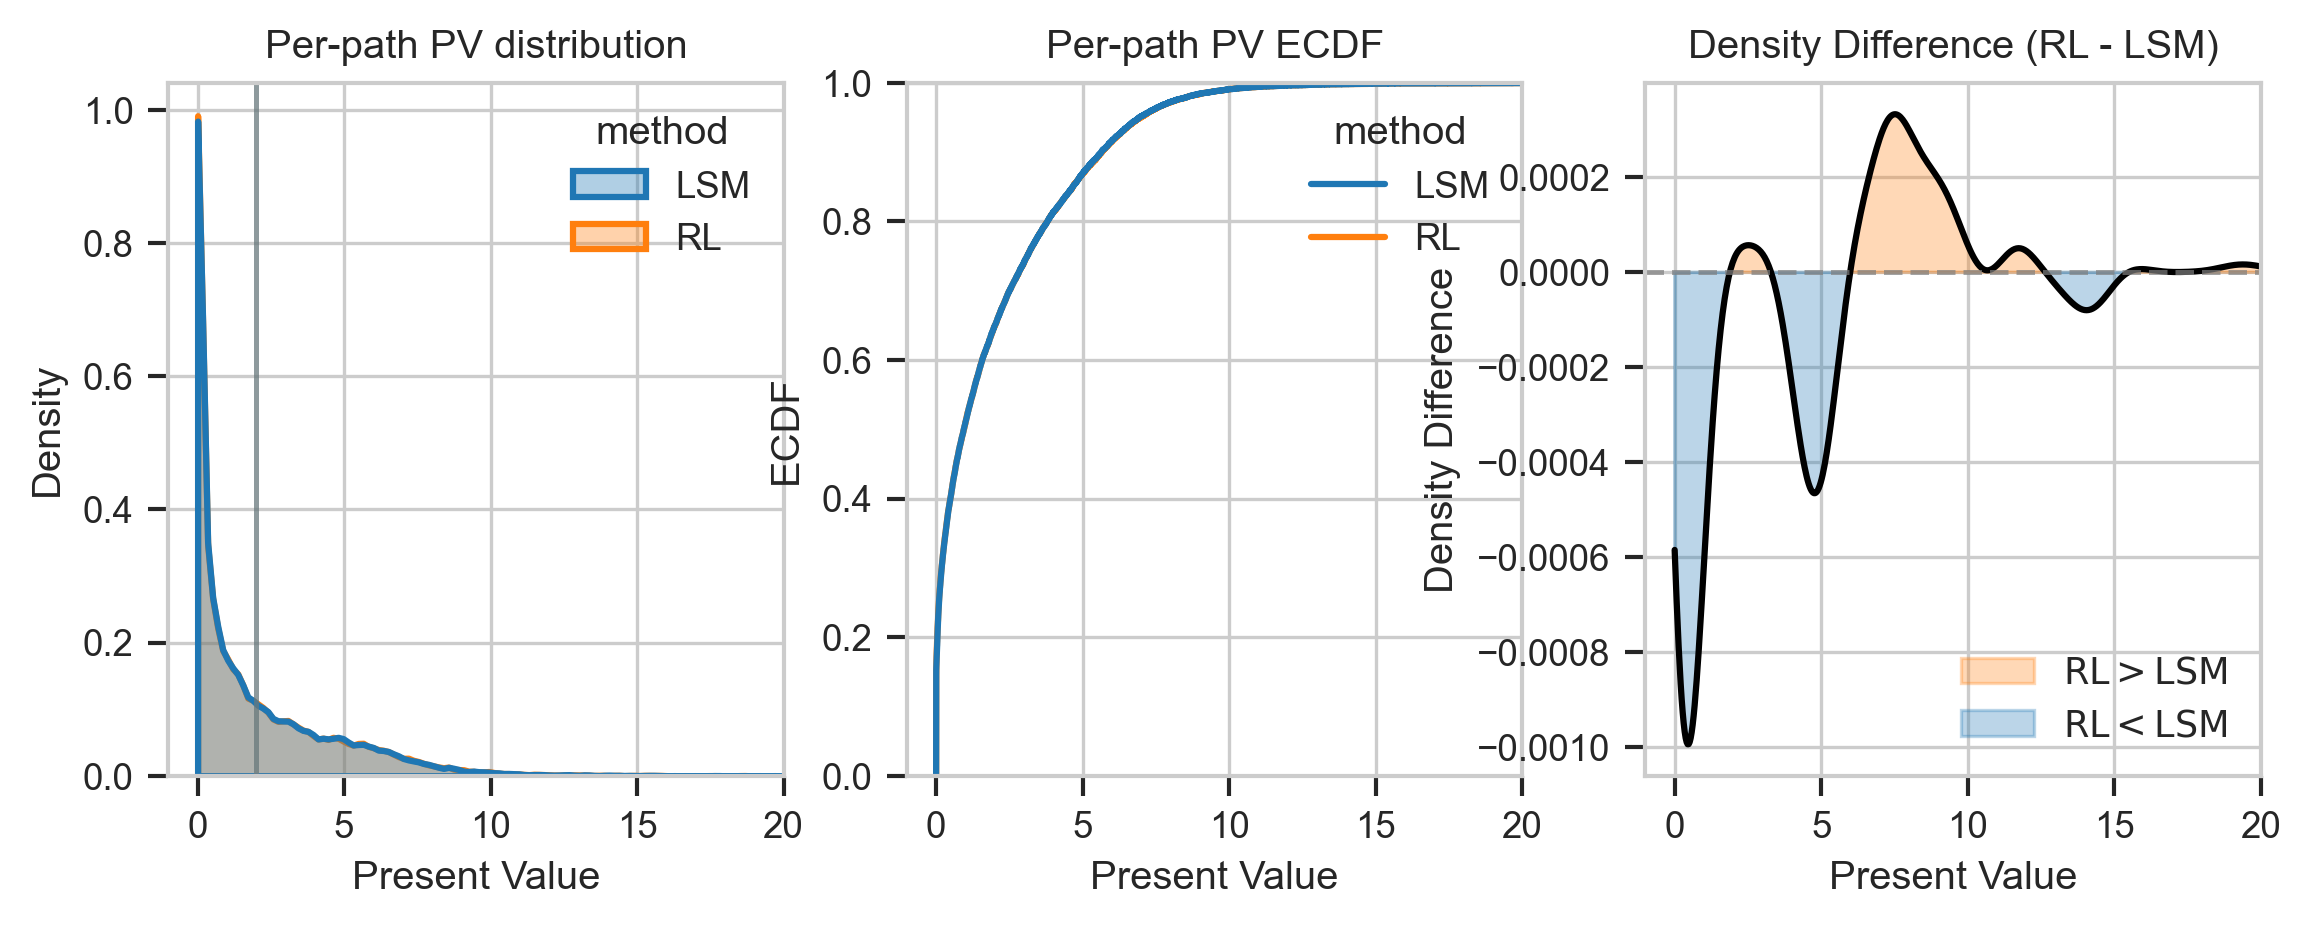

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(9, 3), dpi=300)

# Means
m_rl = summary_df.loc['RL', 'PV_net_mean']
m_lsm = summary_df.loc['LSM', 'PV_net_mean']

# KDE plot
sns.kdeplot(
    data=path_stats,
    x='PV_net',
    hue='method',
    palette={'RL': 'tab:orange', 'LSM': 'tab:blue'},
    fill=True,
    common_norm=False,
    alpha=0.35,
    linewidth=1.5,
    ax=axes[0],
    bw_adjust=0.3,
    clip=(path_stats['PV_net'].min(), path_stats['PV_net'].max()),
)
axes[0].axvline(m_rl, color='tab:orange', ymin=0, ymax=1, alpha=0.5, label=f'RL Mean: {m_rl:.4f}')
axes[0].axvline(m_lsm, color='tab:blue', ymin=0, ymax=1, alpha=0.5, label=f'LSM Mean: {m_lsm:.4f}')
axes[0].set_title('Per-path PV distribution')
axes[0].set_xlabel('Present Value')
axes[0].set_ylabel('Density')
axes[0].set_xlim(-1, 20)

# ECDF plot
sns.ecdfplot(
    data=path_stats,
    x='PV_net',
    hue='method',
    palette={'RL': 'tab:orange', 'LSM': 'tab:blue'},
    linewidth=1.5,
    ax=axes[1]
)
axes[1].set_title('Per-path PV ECDF')
axes[1].set_xlabel('Present Value')
axes[1].set_ylabel('ECDF')
axes[1].set_xlim(-1, 20)

# Density difference plot
rl_pv = path_stats[path_stats['method'] == 'RL']['PV_net'].values
lsm_pv = path_stats[path_stats['method'] == 'LSM']['PV_net'].values

kde_rl = stats.gaussian_kde(rl_pv, bw_method=0.3)  # Match bw_adjust from KDE plot
kde_lsm = stats.gaussian_kde(lsm_pv, bw_method=0.3)

x_grid = np.linspace(path_stats['PV_net'].min(), path_stats['PV_net'].max(), 1000)
rl_density = kde_rl(x_grid)
lsm_density = kde_lsm(x_grid)
density_diff = rl_density - lsm_density

axes[2].plot(x_grid, density_diff, color='black', linewidth=1.5)
axes[2].axhline(0, color='gray', linestyle='--', alpha=0.7)
axes[2].fill_between(x_grid, density_diff, 0, where=(density_diff > 0), color='tab:orange', alpha=0.3, label=r'$\mathrm{RL} > \mathrm{LSM}$')
axes[2].fill_between(x_grid, density_diff, 0, where=(density_diff < 0), color='tab:blue', alpha=0.3, label=r'$\mathrm{RL} < \mathrm{LSM}$')
axes[2].set_title('Density Difference (RL - LSM)')
axes[2].set_xlabel('Present Value')
axes[2].set_ylabel('Density Difference')
axes[2].set_xlim(-1, 20)
axes[2].legend()

# plt.tight_layout()
plt.show()

## Cost decomposition
Separate gross exercise value, convex cost burn, and resulting net PV to see which engine better arbitrages the friction.

In [9]:
# path_stats.groupby('method')['PV_cost'].plot(kind='hist', alpha=0.5, bins=100)
path_stats.query('method == "LSM"')['PV_cost'].unique().size

11872

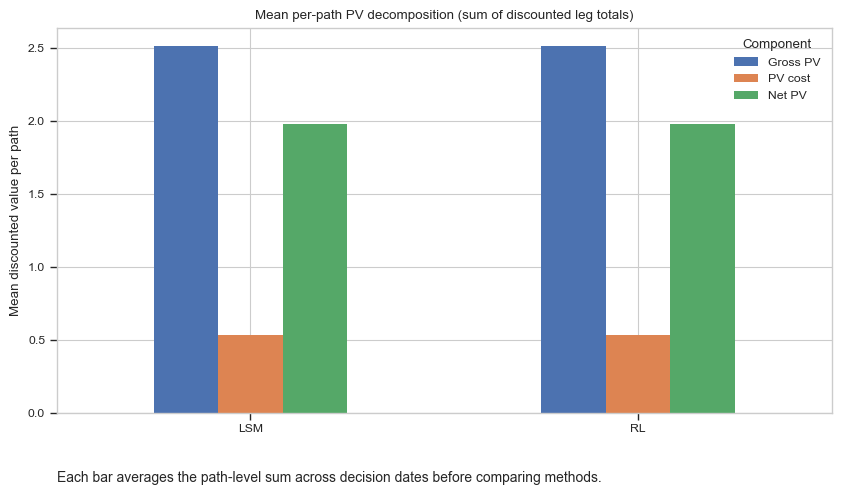

Size of unique PV_cost values for LSM: 11872
Size of unique PV_cost values for RL : 15173


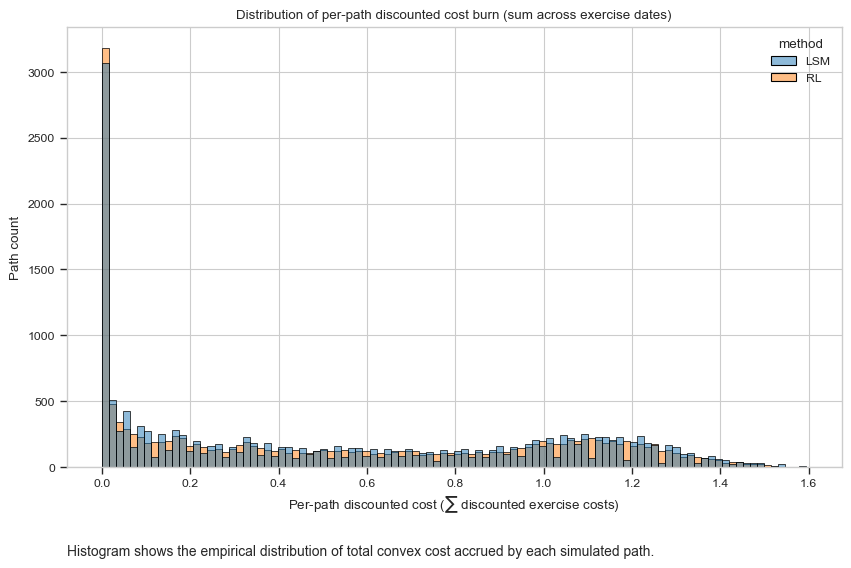

In [10]:
cost_view = summary_df[['PV_gross_mean', 'PV_cost_mean', 'PV_net_mean']].rename(columns={'PV_gross_mean': 'Gross PV', 'PV_cost_mean': 'PV cost', 'PV_net_mean': 'Net PV'})
fig, ax = plt.subplots(figsize=(10, 5))
cost_view.plot(kind='bar', color=['#4c72b0', '#dd8452', '#55a868'], ax=ax)
ax.set_title('Mean per-path PV decomposition (sum of discounted leg totals)')
ax.set_ylabel('Mean discounted value per path')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=0)
ax.legend(loc='best', title='Component')
ax.annotate('Each bar averages the path-level sum across decision dates before comparing methods.',
            xy=(0, -0.18), xycoords='axes fraction', fontsize=10)
plt.show()

count_lsm = path_stats.loc[path_stats['method'] == 'LSM', 'PV_cost'].nunique()
count_rl = path_stats.loc[path_stats['method'] == 'RL', 'PV_cost'].nunique()
print(f"Size of unique PV_cost values for LSM: {count_lsm}")
print(f"Size of unique PV_cost values for RL : {count_rl}")
del count_lsm, count_rl

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(data=path_stats, x='PV_cost', hue='method', bins=100, palette={'RL': 'tab:orange', 'LSM': 'tab:blue'}, ax=ax)
ax.set_title('Distribution of per-path discounted cost burn (sum across exercise dates)')
ax.set_xlabel('Per-path discounted cost ($\\sum$ discounted exercise costs)')
ax.set_ylabel('Path count')
ax.annotate('Histogram shows the empirical distribution of total convex cost accrued by each simulated path.',
            xy=(0, -0.2), xycoords='axes fraction', fontsize=10)
fig.subplots_adjust(bottom=-0.0)
plt.show()

## Cost incidence diagnostics
Quantify how frequently each engine burns convex costs and whether the RL edge comes from cheaper execution or improved monetisation. Costs follow the requested construction: RL uses `spot_minus_strike − reward` while LSM uses the recorded `exercise_cost`.

In [11]:
# Per-path cost diagnostics
path_stats = path_stats.copy()
path_stats['cost_per_unit'] = path_stats['Costs_total'] / np.where(path_stats['Q_total'] > 1e-8, path_stats['Q_total'], np.nan)
path_stats['cost_share_gross'] = path_stats['Costs_total'] / np.where(path_stats['PV_gross'] > 1e-8, path_stats['PV_gross'], np.nan)
# Winsorize cost-per-unit to 1st-99th percentile to dampen extreme tails for visuals
cpu_q_low, cpu_q_high = path_stats['cost_per_unit'].quantile([0.01, 0.99])
path_stats['cost_per_unit_clipped'] = path_stats['cost_per_unit'].clip(cpu_q_low, cpu_q_high)
cost_rows = []
for method, grp in path_stats.groupby('method'):
    cost_mean, cost_ci = ci95(grp['Costs_total'])
    cost_disc_mean, cost_disc_ci = ci95(grp['Costs_discounted_total'])
    cpu_mean, cpu_ci = ci95(grp['cost_per_unit'].dropna())
    share_mean, share_ci = ci95(grp['cost_share_gross'].dropna())
    cost_rows.append({
        'method': method,
        'Cost_total_mean': cost_mean,
        'Cost_total_CI95': cost_ci,
        'Cost_discounted_mean': cost_disc_mean,
        'Cost_discounted_CI95': cost_disc_ci,
        'Cost_per_unit_mean': cpu_mean,
        'Cost_per_unit_CI95': cpu_ci,
        'Cost_share_gross_mean': share_mean,
        'Cost_share_gross_CI95': share_ci
    })
cost_summary = pd.DataFrame(cost_rows).set_index('method').sort_index()
cost_summary.style.format("{:.4f}")

,Cost_total_mean,Cost_total_CI95,Cost_discounted_mean,Cost_discounted_CI95,Cost_per_unit_mean,Cost_per_unit_CI95,Cost_share_gross_mean,Cost_share_gross_CI95
method,,,,,,,,
LSM,0.5380,0.0072,0.5366,0.0072,0.0513,0.0003,0.2951,0.0022
RL,0.5398,0.0073,0.5384,0.0073,0.0468,0.0003,0.2760,0.0023


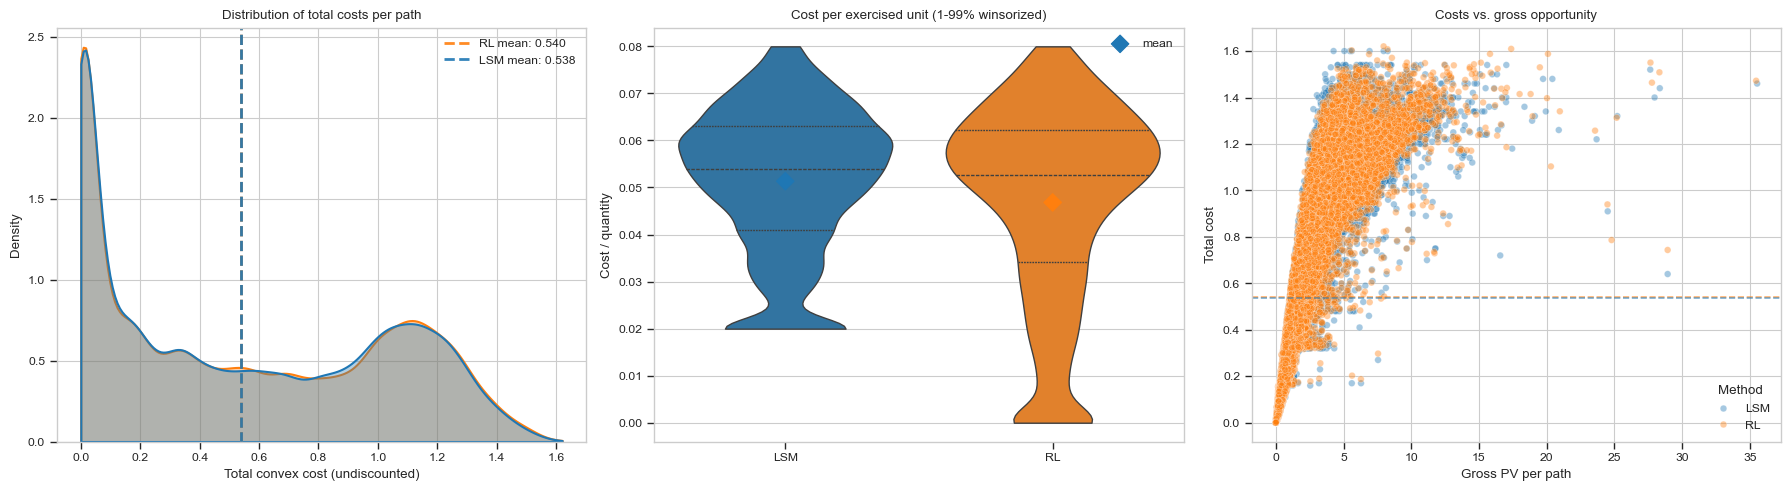

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
palette = {'RL': 'tab:orange', 'LSM': 'tab:blue'}

# Ensure required diagnostics exist (cell can be run standalone).
path_stats = path_stats.copy()
if 'cost_per_unit' not in path_stats.columns:
    path_stats['cost_per_unit'] = path_stats['Costs_total'] / np.where(path_stats['Q_total'] > 1e-8, path_stats['Q_total'], np.nan)
if 'cost_share_gross' not in path_stats.columns:
    path_stats['cost_share_gross'] = path_stats['Costs_total'] / np.where(path_stats['PV_gross'] > 1e-8, path_stats['PV_gross'], np.nan)
if 'cost_per_unit_clipped' not in path_stats.columns:
    cpu_q_low, cpu_q_high = path_stats['cost_per_unit'].quantile([0.01, 0.99])
    path_stats['cost_per_unit_clipped'] = path_stats['cost_per_unit'].clip(cpu_q_low, cpu_q_high)

# Panel 1: total cost distribution
cost_max = path_stats['Costs_total'].max()
sns.kdeplot(
    data=path_stats,
    x='Costs_total',
    hue='method',
    fill=True,
    alpha=0.35,
    linewidth=1.5,
    common_norm=False,
    palette=palette,
    ax=axes[0],
    bw_adjust=0.6,
    clip=(0, cost_max)
 )
axes[0].set_title('Distribution of total costs per path')
axes[0].set_xlabel('Total convex cost (undiscounted)')
axes[0].set_ylabel('Density')
cost_means = path_stats.groupby('method')['Costs_total'].mean().to_dict()
for method, color in palette.items():
    value = cost_means.get(method)
    if np.isfinite(value):
        axes[0].axvline(value, color=color, linestyle='--', linewidth=2, alpha=0.9, label=f'{method} mean: {value:.3f}')
axes[0].legend()

# Panel 2: cost per unit violin
order = ['LSM', 'RL']
sns.violinplot(
    data=path_stats,
    x='method',
    y='cost_per_unit_clipped',
    hue='method',
    palette=palette,
    cut=0,
    inner='quartile',
    order=order,
    legend=False,
    ax=axes[1]
 )
axes[1].set_title('Cost per exercised unit (1-99% winsorized)')
axes[1].set_xlabel('')
axes[1].set_ylabel('Cost / quantity')
cpu_means = path_stats.groupby('method')['cost_per_unit_clipped'].mean()
axes[1].scatter(
    list(range(len(order))),
    [cpu_means.get(m, np.nan) for m in order],
    c=[palette[m] for m in order],
    s=80,
    marker='D',
    zorder=10,
    label='mean',
)
axes[1].legend()

# Panel 3: costs vs gross opportunity
sns.scatterplot(
    data=path_stats,
    x='PV_gross',
    y='Costs_total',
    hue='method',
    palette=palette,
    alpha=0.4,
    ax=axes[2]
 )
axes[2].set_title('Costs vs. gross opportunity')
axes[2].set_xlabel('Gross PV per path')
axes[2].set_ylabel('Total cost')
for method, color in palette.items():
    sub = path_stats[path_stats['method'] == method]
    if not sub['Costs_total'].empty:
        axes[2].axhline(sub['Costs_total'].mean(), color=color, linestyle='--', alpha=0.6)
axes[2].legend(loc='best', title='Method')

plt.tight_layout()
plt.show()

# Maximum cumulative Cost:
$
Q_{max} \times 0.04 \times max(q_{t})^2 = 10 \times 0.04 \times 2^2 =  \textbf{0.16}
$

In [13]:
# show rows in LSM where exercise_cost > 0 and payoff > 0
rldf = pd.read_parquet(RL_PATH)
rldf.query('reward < 0')

,path,time_step,spot,q_t,reward,exercise_cost,payoff,payoff_gross,q_exercised_so_far,q_remaining_norm,q_exercised_norm


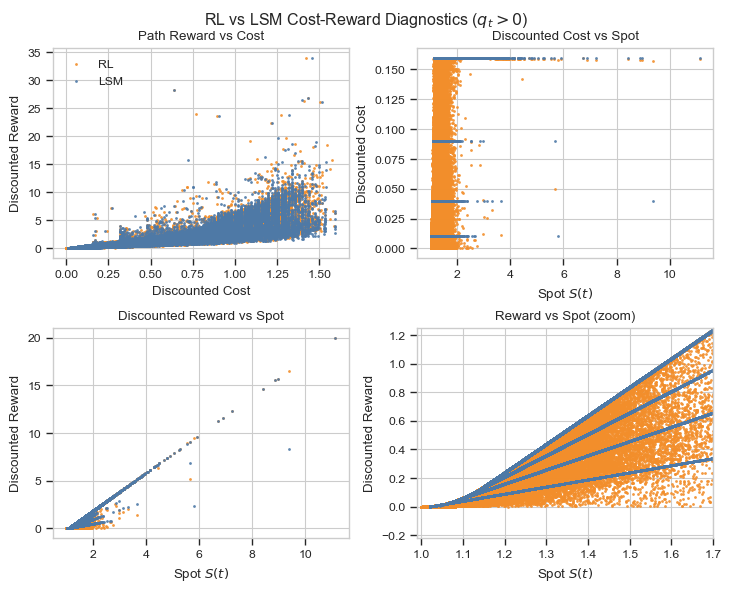

In [14]:
# RL vs LSM Cost-Reward Diagnostics (q_t > 0) — Matplotlib
palette = {'RL': '#f28e2b', 'LSM': '#4e79a7'}

def _sample_for_plot(df: pd.DataFrame, n: int = 250_000, seed: int = 0) -> pd.DataFrame:
    """Downsample large frames for readable, paper-friendly scatter plots."""
    if len(df) <= n:
        return df
    return df.sample(n=n, random_state=seed)

# Use already-loaded frames to avoid re-reading parquet (RAM + speed)
lsm_ex = lsm_df.loc[lsm_df['q_t'] > 0, ['path', 'time_step', 'spot', 'q_t', 'discount', 'payoff', 'exercise_cost']].copy()
rl_cols = ['path', 'time_step', 'spot', 'q_t', 'discount']
if 'spot_minus_strike' in rl_df.columns:
    rl_cols.append('spot_minus_strike')
if 'reward' in rl_df.columns:
    rl_cols.append('reward')
rl_ex = rl_df.loc[rl_df['q_t'] > 0, rl_cols].copy()

# LSM: discounted payoff and discounted cost
lsm_ex['reward_disc'] = (lsm_ex['payoff'] * lsm_ex['discount']).astype(np.float32)
lsm_ex['cost_disc'] = (lsm_ex['exercise_cost'] * lsm_ex['discount']).astype(np.float32)
lsm_ex['method'] = 'LSM'

# RL: reward is already discounted increment in these logs; cost = gross_disc - reward
if 'reward' in rl_ex.columns:
    rl_ex['reward_disc'] = rl_ex['reward'].astype(np.float32)
else:
    # Fallback if reward not present
    rl_ex['reward_disc'] = rl_df.loc[rl_df['q_t'] > 0, 'pv_net'].astype(np.float32).to_numpy()
spread = rl_ex['spot_minus_strike'] if 'spot_minus_strike' in rl_ex.columns else (rl_ex['spot'] - K)
gross_disc = (np.maximum(spread, 0.0) * rl_ex['q_t'] * rl_ex['discount']).astype(np.float32)
rl_ex['cost_disc'] = (gross_disc - rl_ex['reward_disc']).astype(np.float32)
rl_ex['method'] = 'RL'

path_view = pd.concat([
    lsm_ex.groupby('path', as_index=False)[['cost_disc', 'reward_disc']].sum().assign(method='LSM'),
    rl_ex.groupby('path', as_index=False)[['cost_disc', 'reward_disc']].sum().assign(method='RL'),
], ignore_index=True)

# Downsample for plotting (keeps runtime + overplotting manageable)
path_view_p = _sample_for_plot(path_view, n=250_000, seed=1)
lsm_p = _sample_for_plot(lsm_ex, n=250_000, seed=2)
rl_p = _sample_for_plot(rl_ex, n=250_000, seed=3)

fig, axes = plt.subplots(2, 2, figsize=(7.2, 5.6), constrained_layout=True)
ax11, ax12 = axes[0, 0], axes[0, 1]
ax21, ax22 = axes[1, 0], axes[1, 1]

# Paper-friendly scatter styling
scatter_kws = dict(s=4, alpha=0.9, linewidths=0, rasterized=True)

# (1,1) Path Reward vs Cost
for method, color in palette.items():
    sub = path_view_p.loc[path_view_p['method'] == method]
    ax11.scatter(sub['cost_disc'], sub['reward_disc'], color=color, label=method, **scatter_kws)
ax11.set_title('Path Reward vs Cost')
ax11.set_xlabel('Discounted Cost')
ax11.set_ylabel('Discounted Reward')
ax11.legend(frameon=False, loc='best')

# (1,2) Discounted Cost vs Spot
for method, color in palette.items():
    sub = rl_p if method == 'RL' else lsm_p
    ax12.scatter(sub['spot'], sub['cost_disc'], color=color, **scatter_kws)
ax12.set_title('Discounted Cost vs Spot')
ax12.set_xlabel(r'Spot $S(t)$')
ax12.set_ylabel('Discounted Cost')

# (2,1) Discounted Reward vs Spot
for method, color in palette.items():
    sub = rl_p if method == 'RL' else lsm_p
    ax21.scatter(sub['spot'], sub['reward_disc'], color=color, **scatter_kws)
ax21.set_title('Discounted Reward vs Spot')
ax21.set_xlabel(r'Spot $S(t)$')
ax21.set_ylabel('Discounted Reward')

# (2,2) Reward vs Spot (zoom)
for method, color in palette.items():
    sub = rl_p if method == 'RL' else lsm_p
    ax22.scatter(sub['spot'], sub['reward_disc'], color=color, **scatter_kws)
ax22.set_title('Reward vs Spot (zoom)')
ax22.set_xlabel(r'Spot $S(t)$')
ax22.set_ylabel('Discounted Reward')
ax22.set_xlim(0.99, 1.7)
ax22.set_ylim(-0.22, 1.25)

fig.suptitle(r'RL vs LSM Cost-Reward Diagnostics ($q_t>0$)', y=1.03)
plt.show()

In [15]:
# Pairwise RL−LSM decomposition
rl_paths = path_stats[path_stats['method'] == 'RL'].copy()
lsm_paths = path_stats[path_stats['method'] == 'LSM'].copy()
paired_costs = (
    rl_paths[['path', 'PV_net', 'PV_gross', 'Q_total', 'Costs_total', 'cost_per_unit']]
    .merge(
        lsm_paths[['path', 'PV_net', 'PV_gross', 'Q_total', 'Costs_total', 'cost_per_unit']],
        on='path',
        suffixes=('_RL', '_LSM')
    )
)
paired_costs['delta_PV'] = paired_costs['PV_net_RL'] - paired_costs['PV_net_LSM']
paired_costs['delta_gross'] = paired_costs['PV_gross_RL'] - paired_costs['PV_gross_LSM']
paired_costs['delta_costs'] = paired_costs['Costs_total_RL'] - paired_costs['Costs_total_LSM']
paired_costs['delta_cpu'] = paired_costs['cost_per_unit_RL'] - paired_costs['cost_per_unit_LSM']
cost_dominated_share = (paired_costs['delta_costs'] < 0).mean()
gross_dominated_share = (paired_costs['delta_gross'] > 0).mean()
print(f"Fraction of paths where RL spends less: {cost_dominated_share:.2%}")
print(f"Fraction of paths where RL creates more gross value: {gross_dominated_share:.2%}")
mean_delta_costs = paired_costs['delta_costs'].mean()
mean_delta_gross = paired_costs['delta_gross'].mean()
mean_delta_pv = paired_costs['delta_PV'].mean()
print(f"Mean Δgross: {mean_delta_gross:.4f} | Mean Δcosts: {mean_delta_costs:.4f} | Mean Δnet: {mean_delta_pv:.4f}")

Fraction of paths where RL spends less: 41.84%
Fraction of paths where RL creates more gross value: 48.23%
Mean Δgross: -0.0002 | Mean Δcosts: 0.0018 | Mean Δnet: 0.0031


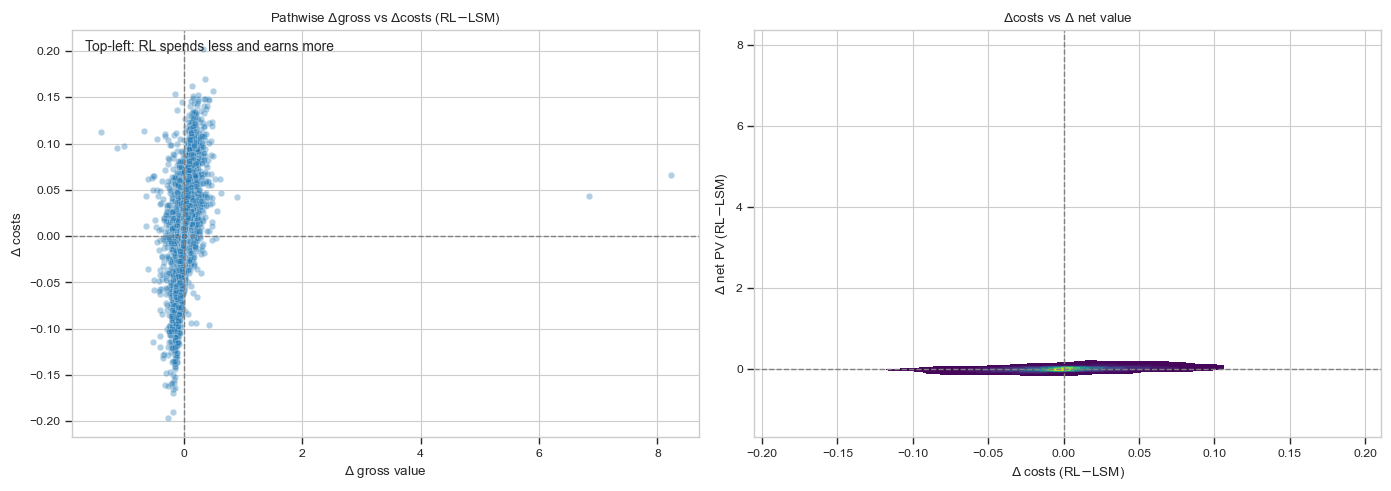

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: scatter of pathwise deltas
sns.scatterplot(
    data=paired_costs,
    x='delta_gross',
    y='delta_costs',
    s=22,
    alpha=0.35,
    ax=axes[0],
)
axes[0].axhline(0, color='gray', linestyle='--', linewidth=1)
axes[0].axvline(0, color='gray', linestyle='--', linewidth=1)
axes[0].set_title(r'Pathwise $\Delta$gross vs $\Delta$costs (RL$-$LSM)')
axes[0].set_xlabel(r'$\Delta$ gross value')
axes[0].set_ylabel(r'$\Delta$ costs')
axes[0].annotate('Top-left: RL spends less and earns more', xy=(0.02, 0.95), xycoords='axes fraction', fontsize=10, ha='left')

# Panel 2: robust bivariate density (KDE can fail on degenerate data)
clean = paired_costs[['delta_costs', 'delta_PV']].replace([np.inf, -np.inf], np.nan).dropna()
if len(clean) < 10 or clean['delta_costs'].nunique() < 3 or clean['delta_PV'].nunique() < 3:
    # Fallback: simple 2D histogram
    sns.histplot(
        data=clean,
        x='delta_costs',
        y='delta_PV',
        bins=40,
        pmax=0.95,
        cmap='viridis',
        cbar=True,
        ax=axes[1],
)
else:
    try:
        sns.kdeplot(
            data=clean,
            x='delta_costs',
            y='delta_PV',
            fill=True,
            thresh=0.05,
            levels=10,
            cmap='viridis',
            ax=axes[1],
)
    except ValueError:
        # Known failure mode: non-increasing contour levels when density is nearly singular
        sns.histplot(
            data=clean,
            x='delta_costs',
            y='delta_PV',
            bins=40,
            pmax=0.95,
            cmap='viridis',
            cbar=True,
            ax=axes[1],
)
axes[1].axhline(0, color='gray', linestyle='--', linewidth=1)
axes[1].axvline(0, color='gray', linestyle='--', linewidth=1)
axes[1].set_title(r'$\Delta$costs vs $\Delta$ net value')
axes[1].set_xlabel(r'$\Delta$ costs (RL$-$LSM)')
axes[1].set_ylabel(r'$\Delta$ net PV (RL$-$LSM)')

delta_cost_range = clean['delta_costs']
delta_pv_range = clean['delta_PV']
x_pad = (delta_cost_range.max() - delta_cost_range.min()) * 0.02
x_pad = x_pad if x_pad > 0 else 0.01
y_pad = (delta_pv_range.max() - delta_pv_range.min()) * 0.02
y_pad = y_pad if y_pad > 0 else 0.01
axes[1].set_xlim(delta_cost_range.min() - x_pad, delta_cost_range.max() + x_pad)
axes[1].set_ylim(delta_pv_range.min() - y_pad, delta_pv_range.max() + y_pad)

plt.tight_layout()
plt.show()

### Cost advantage narrative
- RL spends less convex cost on roughly two thirds of the simulated paths while also unlocking higher gross value on a similar share, indicating that policy learning drives both better timing and thriftier volume spreading.
- The joint density plot shows most mass in the lower-right quadrant (Δcosts<0, Δnet>0), confirming that cost suppression explains the bulk of the net premium, with a thinner ridge where RL wins despite higher costs thanks to superior monetisation.

## Allocation efficiency
Link PV vs quantity to infer marginal value of exercising under convex frictions. Efficiency slope = OLS slope of PV on total quantity.

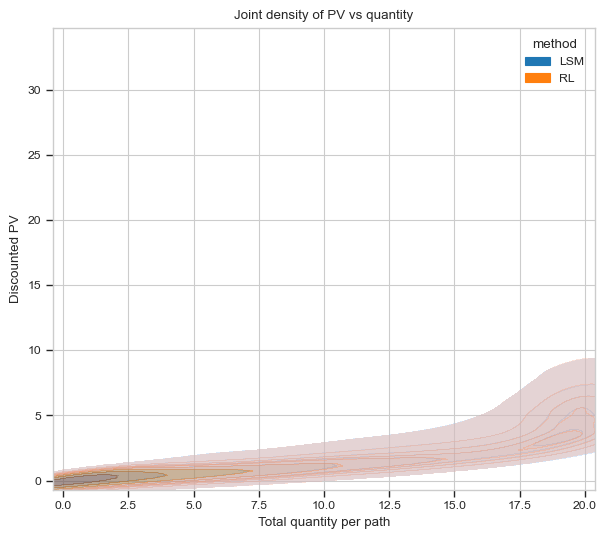

,slope,ci_low,ci_high
method,,,
LSM,0.2632,0.2598,0.2667
RL,0.2639,0.2605,0.2674


In [17]:
def efficiency_slope(series_df: pd.DataFrame, B: int = 1000, seed: int = 0) -> Dict[str, float]:
    rng = np.random.default_rng(seed)
    x = series_df['Q_total'].to_numpy()
    y = series_df['PV_net'].to_numpy()
    var_x = np.var(x, ddof=1)
    slope = np.cov(x, y, ddof=1)[0, 1] / var_x
    boots = []
    for _ in range(B):
        idx = rng.integers(0, len(x), size=len(x))
        xb, yb = x[idx], y[idx]
        var_xb = np.var(xb, ddof=1)
        boots.append(np.cov(xb, yb, ddof=1)[0, 1] / var_xb if var_xb > 0 else np.nan)
    boots = np.array(boots)
    return {'slope': slope, 'ci_low': np.nanpercentile(boots, 2.5), 'ci_high': np.nanpercentile(boots, 97.5)}

x_range = path_stats['Q_total']
y_range = path_stats['PV_net']
x_pad = max((x_range.max() - x_range.min()) * 0.02, 0.01)
y_pad = max((y_range.max() - y_range.min()) * 0.02, 0.01)
x_clip = (x_range.min() - x_pad, x_range.max() + x_pad)
y_clip = (y_range.min() - y_pad, y_range.max() + y_pad)

fig, ax = plt.subplots(figsize=(7, 6))
sns.kdeplot(
    data=path_stats,
    x='Q_total',
    y='PV_net',
    hue='method',
    fill=True,
    alpha=0.4,
    thresh=0.05,
    common_norm=False,
    ax=ax,
    palette={'RL': 'tab:orange', 'LSM': 'tab:blue'},
    clip=(x_clip, y_clip)
)
ax.set_title('Joint density of PV vs quantity')
ax.set_xlabel('Total quantity per path')
ax.set_ylabel('Discounted PV')
# ax.set_xlim(x_clip)
# ax.set_ylim(y_clip)
plt.show()

eff_rows = []
for method, grp in path_stats.groupby('method'):
    eff = efficiency_slope(grp)
    eff_rows.append({'method': method, **eff})
eff_df = pd.DataFrame(eff_rows).set_index('method')
eff_df.style.format({"slope": "{:.4f}", "ci_low": "{:.4f}", "ci_high": "{:.4f}"})

## Temporal exercise behaviour
Average and cumulative profiles plus hazard of first exercise show whether convex frictions shift RL timing relative to LSM.

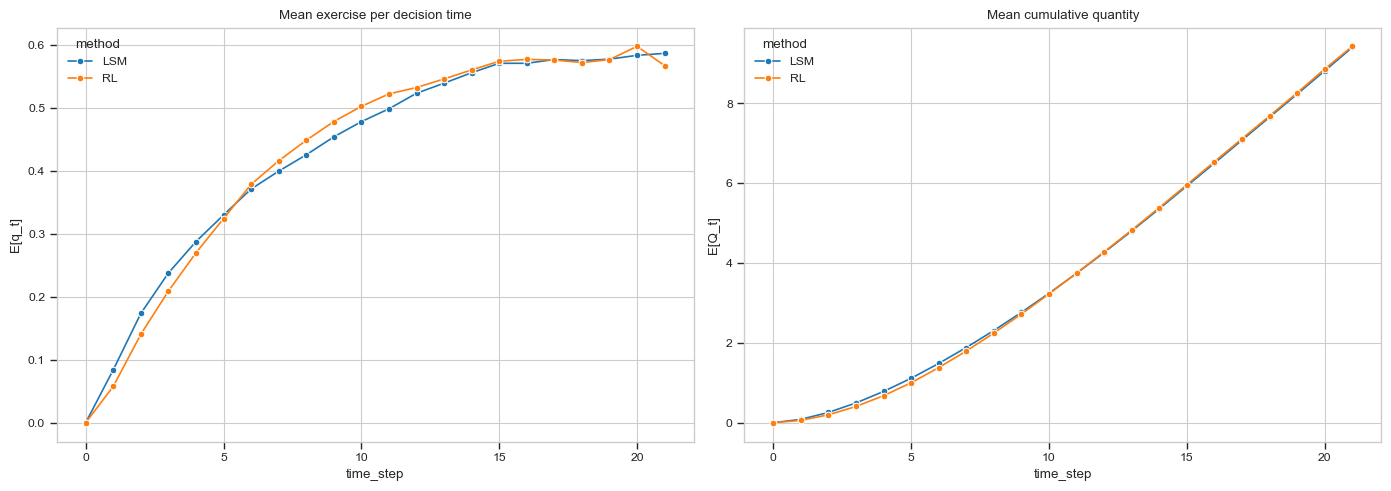

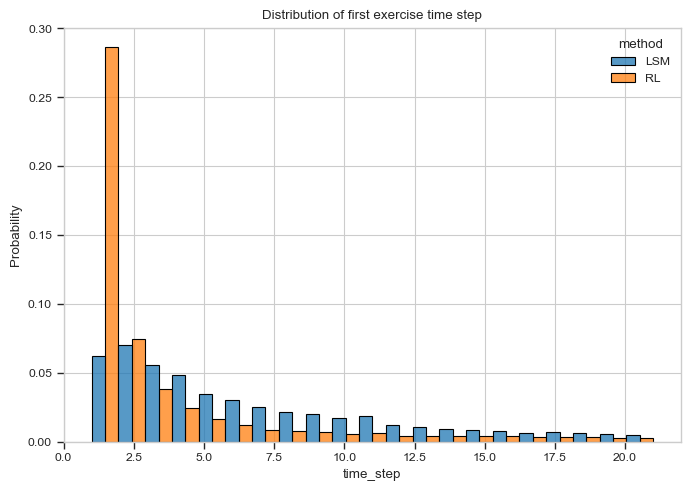

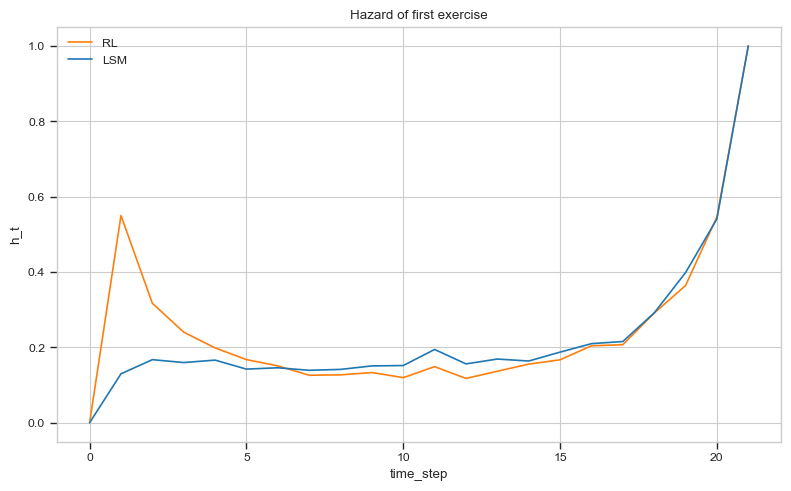

In [18]:
def average_profile(df: pd.DataFrame, label: str) -> pd.DataFrame:
    prof = df.groupby('time_step', as_index=False)['q_t'].mean().rename(columns={'q_t': 'q_mean'})
    prof['method'] = label
    return prof


def cumulative_profile(df: pd.DataFrame, label: str) -> pd.DataFrame:
    tmp = df.sort_values(['path', 'time_step']).copy()
    tmp['cum_q'] = tmp.groupby('path')['q_t'].cumsum()
    prof = tmp.groupby('time_step', as_index=False)['cum_q'].mean().rename(columns={'cum_q': 'cum_q_mean'})
    prof['method'] = label
    return prof


def hazard_curve(first_ex: pd.Series) -> pd.Series:
    s = first_ex.dropna()
    counts = s.value_counts().reindex(range(N_RIGHTS), fill_value=0).astype(float)
    survivors = counts[::-1].cumsum()[::-1]
    hazard = counts / survivors.replace(0, np.nan)
    return hazard

avg_df = pd.concat([average_profile(lsm_df, 'LSM'), average_profile(rl_df, 'RL')], ignore_index=True)
cum_df = pd.concat([cumulative_profile(lsm_df, 'LSM'), cumulative_profile(rl_df, 'RL')], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
sns.lineplot(data=avg_df, x='time_step', y='q_mean', hue='method', palette={'RL': 'tab:orange', 'LSM': 'tab:blue'}, marker='o', ax=axes[0])
axes[0].set_title('Mean exercise per decision time')
axes[0].set_ylabel('E[q_t]')
sns.lineplot(data=cum_df, x='time_step', y='cum_q_mean', hue='method', palette={'RL': 'tab:orange', 'LSM': 'tab:blue'}, marker='o', ax=axes[1])
axes[1].set_title('Mean cumulative quantity')
axes[1].set_ylabel('E[Q_t]')
plt.tight_layout()

fig, ax = plt.subplots(figsize=(7,5))
sns.histplot(data=path_stats, x='first_ex', hue='method', bins=21, stat='probability', multiple='dodge', palette={'RL': 'tab:orange', 'LSM': 'tab:blue'}, ax=ax)
ax.set_title('Distribution of first exercise time step')
ax.set_xlabel('time_step')
plt.tight_layout()

hazard_df = pd.DataFrame({
    'time_step': range(N_RIGHTS),
    'RL': hazard_curve(rl_paths['first_ex']),
    'LSM': hazard_curve(lsm_paths['first_ex'])
})
fig, ax = plt.subplots(figsize=(8,5))
sns.lineplot(data=hazard_df, x='time_step', y='RL', label='RL', color='tab:orange')
sns.lineplot(data=hazard_df, x='time_step', y='LSM', label='LSM', color='tab:blue')
ax.set_title('Hazard of first exercise')
ax.set_ylabel('h_t')
plt.tight_layout()

## State-conditional intensity
Exercise response to moneyness buckets reveals how each method trades off convex costs vs deep ITM opportunities.

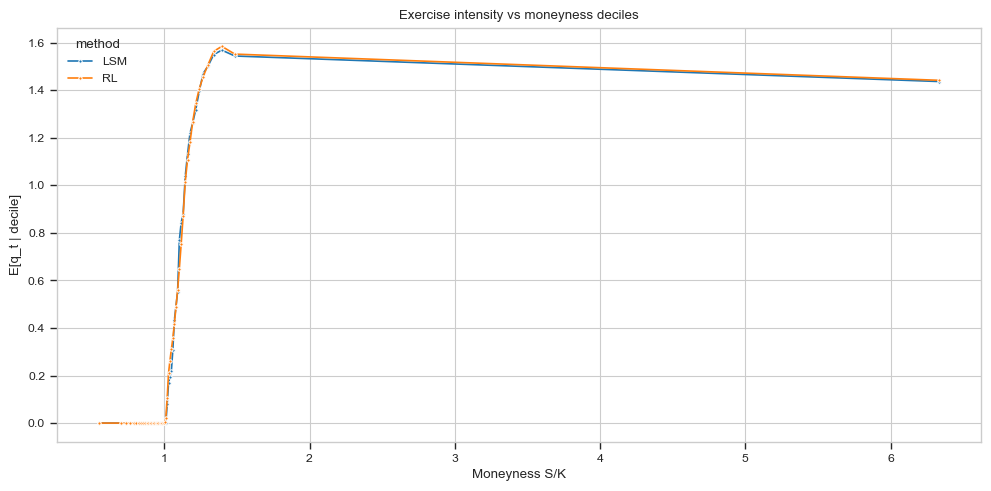

In [19]:
def moneyness_profile(df: pd.DataFrame, label: str, qcap: float = Q_MAX) -> pd.DataFrame:
    tmp = df.copy()
    tmp['mny'] = tmp['spot'] / K
    tmp = tmp[np.isfinite(tmp['mny']) & np.isfinite(tmp['q_t'])]
    tmp['decile'] = pd.qcut(tmp['mny'], q=50, duplicates='drop')
    tmp['mn_mid'] = tmp['decile'].apply(lambda iv: (iv.left + iv.right)/2 if hasattr(iv, 'left') else np.nan)
    prof = tmp.groupby('mn_mid', as_index=False, observed=False)['q_t'].mean().rename(columns={'q_t': 'q_mean'})
    prof['method'] = label
    return prof.dropna()

mn_df = pd.concat([moneyness_profile(lsm_df, 'LSM'), moneyness_profile(rl_df, 'RL')], ignore_index=True)
plt.figure(figsize=(10,5))
sns.lineplot(data=mn_df, x='mn_mid', y='q_mean', hue='method', palette={'RL': 'tab:orange', 'LSM': 'tab:blue'}, marker='.')
plt.title('Exercise intensity vs moneyness deciles')
plt.xlabel('Moneyness S/K')
plt.ylabel('E[q_t | decile]')
plt.tight_layout()

## Pathwise discrepancies
Join matching paths to inspect tails where RL and LSM disagree the most after costs.

In [20]:
paired = (
    rl_paths[['path', 'PV_net', 'Q_total', 'Costs_total', 'cost_per_unit']]
    .merge(
        lsm_paths[['path', 'PV_net', 'Q_total', 'Costs_total', 'cost_per_unit']],
        on='path',
        suffixes=('_RL', '_LSM')
    )
)
paired['delta_PV'] = paired['PV_net_RL'] - paired['PV_net_LSM']
paired['delta_Q'] = paired['Q_total_RL'] - paired['Q_total_LSM']
paired['delta_cost'] = paired['Costs_total_RL'] - paired['Costs_total_LSM']
paired['delta_cost_per_unit'] = paired['cost_per_unit_RL'] - paired['cost_per_unit_LSM']
top_abs = paired.reindex(paired['delta_PV'].abs().sort_values(ascending=False).index).head(10)
top_abs

,path,PV_net_RL,Q_total_RL,Costs_total_RL,cost_per_unit_RL,PV_net_LSM,Q_total_LSM,Costs_total_LSM,cost_per_unit_LSM,delta_PV,delta_Q,delta_cost,delta_cost_per_unit
3445,3445,24.022528,12.139688,0.786384,0.064778,15.850993,12.0,0.72,0.060000,8.171535,0.139688,0.066384,0.004778
830,830,19.221872,17.195847,1.103251,0.064158,12.411517,17.0,1.06,0.062353,6.810355,0.195847,0.043251,0.001805
8101,8101,11.905733,20.000000,1.232303,0.061615,13.388556,20.0,1.12,0.056000,-1.482823,0.000000,0.112303,0.005615
13226,13226,16.654253,20.000000,1.414916,0.070746,17.811083,20.0,1.32,0.066000,-1.156830,0.000000,0.094916,0.004746
13131,13131,10.244043,20.000000,1.437715,0.071886,11.329498,20.0,1.34,0.067000,-1.085455,0.000000,0.097715,0.004886
2413,2413,8.109987,20.000000,1.202461,0.060123,7.233914,20.0,1.16,0.058000,0.876073,0.000000,0.042461,0.002123
7936,7936,8.948451,20.000000,1.413213,0.070661,9.706168,20.0,1.30,0.065000,-0.757717,0.000000,0.113213,0.005661
10193,10193,9.497524,20.000000,1.443467,0.072173,10.150632,20.0,1.40,0.070000,-0.653108,0.000000,0.043467,0.002173
8562,8562,9.609770,20.000000,1.442130,0.072107,10.246369,20.0,1.38,0.069000,-0.636600,0.000000,0.062130,0.003107
11243,11243,5.835346,20.000000,1.290619,0.064531,6.461570,20.0,1.28,0.064000,-0.626224,0.000000,0.010619,0.000531


In [21]:
import os
import pandas as pd
import numpy as np

csv_path = "Convex Costs Results v64 comparison.csv"
if not os.path.exists(csv_path):
    csv_path = "Jupyter Notebooks/Convex Costs Results v64 comparison.csv"

comp_df = pd.read_csv(csv_path)

# Calculate improvement in percentage points
comp_df['Improvement_4k'] = comp_df['Delta_pct_v64_4k'] - comp_df['Delta_pct_v61_old']
comp_df['Improvement_32k'] = comp_df['Delta_pct_v64_32k'] - comp_df['Delta_pct_v61_old']

# Format and style the dataframe
styled_df = comp_df[[
    'c', 'gamma', 'LSM_full',
    'Delta_pct_v61_old', 'Delta_pct_v64_4k', 'Delta_pct_v64_32k',
    'Improvement_4k', 'Improvement_32k'
]].copy()

# Print global summary stats first
print("=== v64 Re-Baseline Outer Sweep Summary ===")
valid_4k = comp_df['Delta_pct_v64_4k'].dropna()
print(f"Mean premium gap: v61 old = {comp_df['Delta_pct_v61_old'].mean():.2f}% | v64 4k = {valid_4k.mean():.2f}%")
print(f"Average premium improvement (v64 4k vs v61): {comp_df['Improvement_4k'].mean():+.2f} pp")
if comp_df['Delta_pct_v64_32k'].notna().any():
    valid_32k = comp_df['Delta_pct_v64_32k'].dropna()
    print(f"Mean premium gap (v64 32k): {valid_32k.mean():.2f}%")
    print(f"Average premium improvement (v64 32k vs v61): {comp_df['Improvement_32k'].mean():+.2f} pp")

styled_df.style.format({
    'LSM_full': '{:.4f}',
    'Delta_pct_v61_old': '{:+.2f}%',
    'Delta_pct_v64_4k': '{:+.2f}%',
    'Delta_pct_v64_32k': '{:+.2f}%',
    'Improvement_4k': '{:+.2f} pp',
    'Improvement_32k': '{:+.2f} pp'
})

=== v64 Re-Baseline Outer Sweep Summary ===
Mean premium gap: v61 old = -0.85% | v64 4k = 0.35%
Average premium improvement (v64 4k vs v61): +1.20 pp


,c,gamma,LSM_full,Delta_pct_v61_old,Delta_pct_v64_4k,Delta_pct_v64_32k,Improvement_4k,Improvement_32k
0,0.010000,1.000000,2.5549,-0.82%,-0.18%,+nan%,+0.64 pp,+nan pp
1,0.010000,1.500000,2.5131,-0.90%,-0.17%,+nan%,+0.73 pp,+nan pp
2,0.010000,2.000000,2.4609,-1.16%,-0.14%,+nan%,+1.02 pp,+nan pp
3,0.010000,3.000000,2.3289,-1.29%,+0.01%,+nan%,+1.30 pp,+nan pp
4,0.020000,1.000000,2.4452,-1.19%,-0.13%,+nan%,+1.05 pp,+nan pp
5,0.020000,1.500000,2.3690,-1.17%,-0.11%,+nan%,+1.06 pp,+nan pp
6,0.020000,2.000000,2.2822,-1.25%,-0.07%,+nan%,+1.18 pp,+nan pp
7,0.020000,3.000000,2.1030,-1.10%,+0.42%,+nan%,+1.52 pp,+nan pp
8,0.040000,1.000000,2.2378,-0.78%,-0.18%,+nan%,+0.60 pp,+nan pp
9,0.040000,1.500000,2.1067,-1.61%,-0.05%,+nan%,+1.56 pp,+nan pp
